# Start with latent diffusion model

In [1]:
from diffusers import StableDiffusionPipeline
import torch
import numpy as np
from torchvision.utils import save_image as tv_save_image
from torchvision.utils import make_grid as tv_make_grid
from torchvision.io import read_image as tv_read_image
from torchvision.transforms.functional import resize as tv_resize

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10, 5]

/home/zwhuang/.conda/envs/pnpdm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda:0")

tt = lambda x: torch.tensor(x).to(device)

In [3]:
MODEL_NAME = "sd-legacy/stable-diffusion-v1-5"
IMAGE_SIZE = 512

In [4]:
pipeline = StableDiffusionPipeline.from_pretrained(MODEL_NAME)

Loading pipeline components...: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 27.70it/s]


In [5]:
# use FP16 to decrease memory usage and increase speed
pipeline.unet = pipeline.unet.half()
pipeline.vae = pipeline.vae.half()
pipeline.text_encoder = pipeline.text_encoder.half()

pipeline = pipeline.to(device)

## Test that Stable Diffusion model is working

In [6]:
num_samples = 4
prompt = 'Blue butterfly on white flower, green blurred background.'
results = pipeline(
    prompt=[prompt] * num_samples,
    num_inference_steps=50,
    guidance_scale=7.5
)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:07<00:00,  6.41it/s]


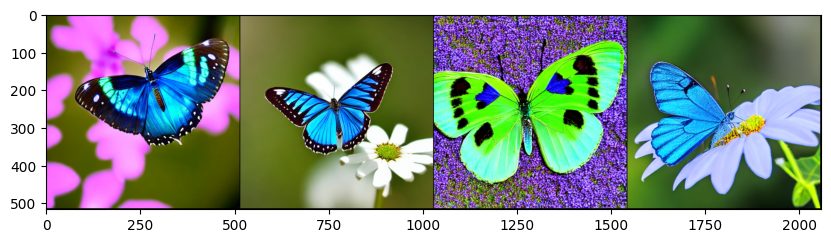

In [7]:
# Convert samples to tensors
tensors = [torch.tensor(np.array(img.convert("RGB"))) for img in results.images]
batch_tensor = torch.stack(tensors).permute(0, 3, 1, 2) / 255.0  # Shape: [B, C, H, W]

# Display images as a grid
grid = tv_make_grid(batch_tensor, nrow=4)
plt.imshow(grid.permute(1, 2, 0))
plt.show()

## Visualizing noise schedule

In [13]:
config = pipeline.scheduler.config
config

FrozenDict([('num_train_timesteps', 1000),
            ('beta_start', 0.00085),
            ('beta_end', 0.012),
            ('beta_schedule', 'scaled_linear'),
            ('trained_betas', None),
            ('skip_prk_steps', True),
            ('set_alpha_to_one', False),
            ('prediction_type', 'epsilon'),
            ('timestep_spacing', 'leading'),
            ('steps_offset', 1),
            ('_use_default_values', ['prediction_type', 'timestep_spacing']),
            ('_class_name', 'PNDMScheduler'),
            ('_diffusers_version', '0.6.0'),
            ('clip_sample', False)])

In [14]:
steps_offset = config.steps_offset
train_timesteps = config.num_train_timesteps
beta_start, beta_end = config.beta_start * train_timesteps, config.beta_end * train_timesteps

beta_d = beta_end**0.5 - beta_start**0.5

# https://github.com/huggingface/diffusers/blob/main/src/diffusers/schedulers/scheduling_pndm.py#L133
# betas = np.linspace(beta_start ** 0.5, beta_end ** 0.5, train_timesteps) ** 2.0

In [155]:
# Convert Stable Diffusion scaled linear schedule (PNDM) to EDM formulation (in terms of sigma)
# https://arxiv.org/pdf/2206.00364
# Appendix C.1

# expects t in [0, 1]
def alpha(t):
    return beta_start * t + beta_start**0.5 * beta_d * t**2 + (beta_d**2.0 / 3.0) * t**3

# expects t in [0, 1000]
def sigma(t):
    return (torch.exp(alpha((t + steps_offset) / train_timesteps)) - 1) ** 0.5

all_sigma = sigma(torch.arange(train_timesteps)).to(device)

# returns t in [0, M)
def sigma_inv(s):
    # subtract a small amount to prevent accidental rounding up
    return torch.searchsorted(all_sigma - 1e-6, s.reshape(-1))

def round_sigma(s):
    return sigma(sigma_inv(s))

tensor(0.0292, device='cuda:0') tensor(14.4627, device='cuda:0')


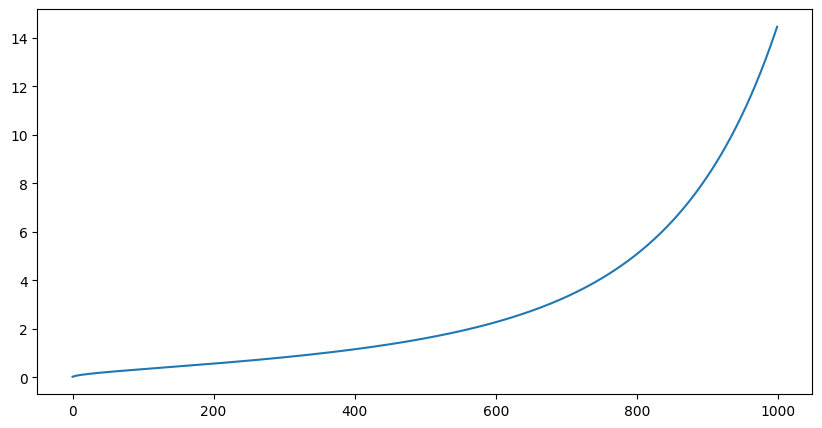

In [16]:
print(all_sigma[0], all_sigma[-1])
plt.plot(all_sigma.cpu())
plt.show()

# Preconditioning latent diffusion for use with EDM sampling

In [17]:
def read_image(path, dtype=torch.float16):
    """
    reads RGB image , converts it to the right shape, and scales it from -1 to 1.
    """
    img = (tv_read_image(path).to(device) / 255.0)[None, :3, :, :]
    img = tv_resize(img, (IMAGE_SIZE, IMAGE_SIZE))
    return (img*2-1).to(dtype).to(device)

def show_image(img):
    """
    Converts an image tensor back into image format (undos read_image).
    Expects an image of shape (1, 3, N, N) scaled from [-1, 1].
    """
    return (img / 2 + 0.5).clamp(0, 1).detach().cpu().squeeze().permute(1, 2, 0).to(torch.float32)

In [18]:
def encode_text(pipeline, text_prompt):
    prompt = [text_prompt]
    text_input = pipeline.tokenizer(
        prompt, padding="max_length", max_length=pipeline.tokenizer.model_max_length, truncation=True, return_tensors="pt")
    text_embeddings = pipeline.text_encoder(
        text_input.input_ids.to(device))[0]
    max_length = text_input.input_ids.shape[-1]
    uncond_input = pipeline.tokenizer(
        [""], padding="max_length", max_length=max_length, return_tensors="pt")
    uncond_embeddings = pipeline.text_encoder(
        uncond_input.input_ids.to(device))[0]
    encoder_hidden_states = torch.cat(
        [uncond_embeddings, text_embeddings])
    return encoder_hidden_states

In [19]:
def encode_image(pipeline, img):
    """
    Expects an image of shape (1, 3, N, N), scaled from -1 to 1.
    """
    assert img.shape == torch.Size([1, 3, IMAGE_SIZE, IMAGE_SIZE]), \
        f"image size is {img.shape} but expected to be 1x3x{IMAGE_SIZE}x{IMAGE_SIZE}"
    with torch.no_grad():
        encoded = pipeline.vae.encode(img).latent_dist.sample() * 0.18215
        return encoded

# decode latent to image space, we need the grad for our likelihood step
def decode_image(pipeline, latents):
    """
    Expects an image of shape (1, 3, N, N), scaled from -1 to 1.
    """
    decoded = pipeline.vae.decode(latents / 0.18215).sample
    return decoded

In [20]:
# Takes a stable diffusion pipeline and runs a single step of denoising, using
# sigma values from the EDM formulation.
def denoise_step(pipeline: StableDiffusionPipeline, x_noisy, s, encoded_text):
    # vp preconditioning with new noise schedule
    c_skip = 1
    c_out = -s
    c_in = 1 / (s ** 2 + 1) ** 0.5
    c_noise = sigma_inv(torch.tensor(s, device=device))

    # we expect sigma(c_noise) > s by a small amount due to quantization error
    missing_noise = torch.sqrt(sigma(c_noise) ** 2 - s ** 2).to(x_noisy.dtype)
    x_noisy = x_noisy + missing_noise * torch.randn_like(x_noisy, dtype=x_noisy.dtype)

    with torch.no_grad():
        latent_model_input = torch.cat([x_noisy] * 2)
        unet_out = pipeline.unet(latent_model_input * c_in,
                             c_noise, encoder_hidden_states=encoded_text).sample

    # hopefully classifier free guidance
    noise_pred_uncond, noise_pred_text = unet_out.chunk(2)
    F = noise_pred_uncond + 7.5 * (noise_pred_text - noise_pred_uncond)
    return c_skip * x_noisy + c_out * F

In [16]:
encoded_text = encode_text(pipeline, "A busy street with cars and a blue sky with a few clouds")

In [17]:
x_clean = read_image(f"images/512/test_image_10.png", dtype=torch.float16)
z_clean = encode_image(pipeline, x_clean)
decoded = decode_image(pipeline, z_clean)

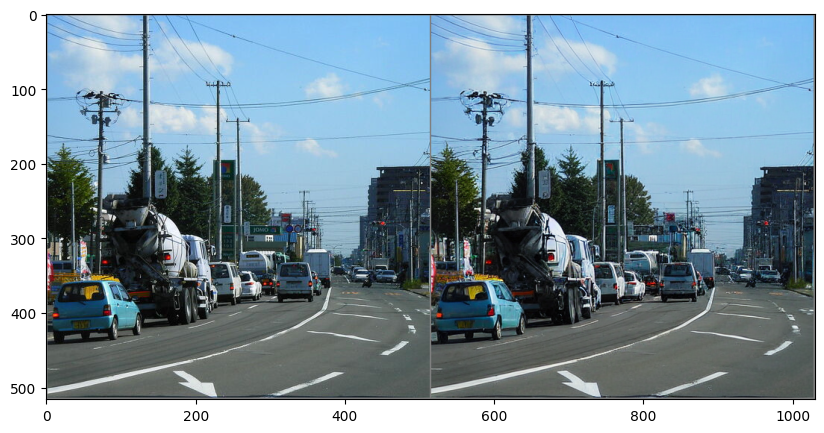

In [18]:
# Checking that encoding and decoding an image doesn't change it
img = tv_make_grid(torch.cat([x_clean, decoded]), nrow=2)
plt.imshow(show_image(img))
plt.show()

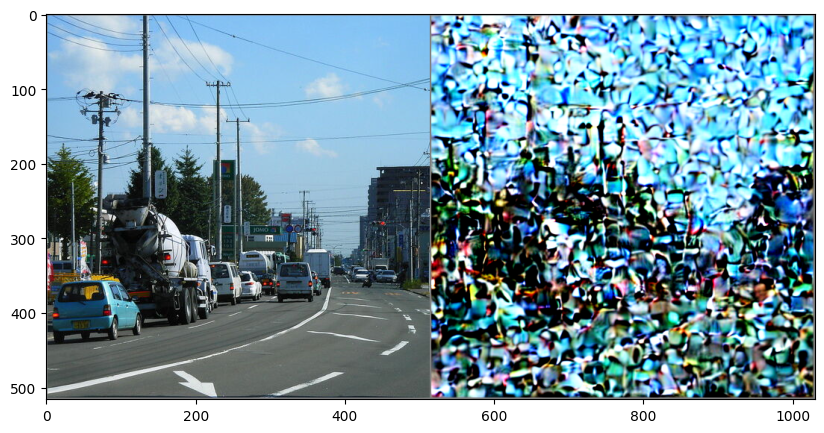

In [19]:
s = 1.0
z_noisy = z_clean + s * torch.randn_like(z_clean)

decoded_noisy = decode_image(pipeline, z_noisy)

img = tv_make_grid(torch.cat([x_clean, decoded_noisy]), nrow=2)
plt.imshow(show_image(img))
plt.show()

In [20]:
z_denoised = denoise_step(pipeline, z_noisy, 1, encoded_text)

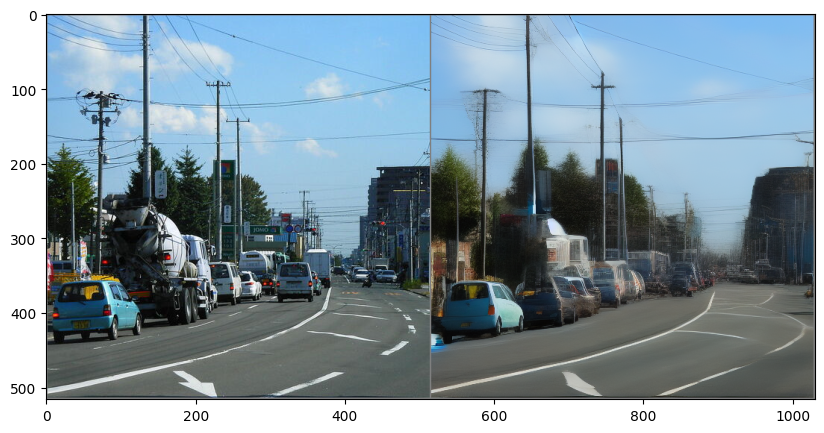

In [21]:
# one-shot denoising is going to look very smooth (but at least it seems to work?)
decoded_denoised = decode_image(pipeline, z_denoised)

img = tv_make_grid(torch.cat([x_clean, decoded_denoised]), nrow=2)
plt.imshow(show_image(img))
plt.show()

In [21]:
# Now that the network is pre-conditioned, we can give it any noise schedule
# (e.g. from VP, VE, EDM, etc) in terms of sigma and denoise using Stable
# Diffusion according to that schedule (no matter the original formulation).
class Schedule:
    pass

class VPSchedule(Schedule):
    def __init__(self, beta_min, beta_d, num_steps, epsilon_s=1e-3):
        self.num_steps = num_steps
            
        def vp_sigma(beta_d, beta_min): return lambda t: (
            np.e ** (0.5 * beta_d * (t ** 2) + beta_min * t) - 1) ** 0.5
            
        sigma_min = vp_sigma(beta_d, beta_min)(t=epsilon_s)
        sigma_max = vp_sigma(beta_d, beta_min)(t=1)

        assert sigma_max <= all_sigma[-1].item(), "Sigma not supported by network"

        def vp_sigma_deriv(beta_d, beta_min): return lambda t: 0.5 * \
            (beta_min + beta_d * t) * (self.sigma(t) + 1 / self.sigma(t))
            
        def vp_sigma_inv(beta_d, beta_min): return lambda sigma: (
            (beta_min ** 2 + 2 * beta_d * (sigma ** 2 + 1).log()).sqrt() - beta_min) / beta_d
        
        vp_beta_d = 2 * (np.log(sigma_min ** 2 + 1) / epsilon_s -
                         np.log(sigma_max ** 2 + 1)) / (epsilon_s - 1)
        vp_beta_min = np.log(sigma_max ** 2 + 1) - 0.5 * vp_beta_d

        step_indices = torch.arange(num_steps, dtype=torch.float32, device=device)
        orig_t_steps = 1 + step_indices / (num_steps - 1) * (epsilon_s - 1)
        self.sigma_steps = vp_sigma(vp_beta_d, vp_beta_min)(orig_t_steps)

        self.s = lambda t: 1 / (1 + self.sigma(t) ** 2).sqrt()
        self.s_deriv = lambda t: - \
            self.sigma(t) * self.sigma_deriv(t) * (self.s(t) ** 3)
        
        self.sigma = vp_sigma(vp_beta_d, vp_beta_min)
        self.sigma_deriv = vp_sigma_deriv(vp_beta_d, vp_beta_min)
        self.sigma_inv = vp_sigma_inv(vp_beta_d, vp_beta_min)

class EDMSchedule(Schedule):
    def __init__(self, sigma_min, sigma_max, rho, num_steps):
        self.num_steps = num_steps
        step_indices = torch.arange(
            num_steps, dtype=torch.float64, device=device)
        self.sigma_steps = (sigma_max ** (1 / rho) + step_indices / (num_steps - 1)
                       * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
        
        self.sigma = lambda t: t
        self.sigma_deriv = lambda t: 1
        self.sigma_inv = lambda sigma: sigma
    
        self.s = lambda t: 1
        self.s_deriv = lambda t: 0

In [22]:
schedule = VPSchedule(0.02, 10, num_steps=200)
# schedule = EDMSchedule(0.0, 10.0, 0.9, num_steps=500)

In [23]:
@torch.no_grad()
def denoise(pipeline, schedule, z_noisy, eta, encoded_text, mode="sde"):
    t_steps = schedule.sigma_inv(schedule.sigma_steps)
    
    # find the smallest t such that sigma(t) < eta
    i_start = torch.min(torch.nonzero(schedule.sigma(t_steps) < eta))

    x_next = z_noisy * schedule.s(t_steps[i_start])

    # 0, ..., N-1
    for i, (t, tn) in enumerate(zip(t_steps[:-1], t_steps[1:])):
        if i < i_start:
            # Skip the steps before i_start.
            continue

        x_cur = x_next

        # Euler step.
        lmbd = 2 if mode == 'sde' else 1

        # print(t, schedule.sigma(t))
        denoised = denoise_step(pipeline, x_cur / schedule.s(t), schedule.sigma(t), encoded_text)
        
        d_cur = (lmbd * schedule.sigma_deriv(t) / schedule.sigma(t) + schedule.s_deriv(t) / schedule.s(t)) * x_cur - \
            lmbd * schedule.sigma_deriv(t) * schedule.s(t) / \
            schedule.sigma(t) * denoised
        x_next = x_cur + (tn - t) * d_cur
        
        # self.save_image(self.decode_image(x_next), f"test-{i:04}.png")

        # Update
        if i != schedule.num_steps - 1 and mode == 'sde':
            n_cur = schedule.s(t) * torch.sqrt(2 * schedule.sigma_deriv(t)
                                               * schedule.sigma(t)) * torch.randn_like(x_cur)
            x_next += torch.sqrt(t - tn) * n_cur

    return x_next

In [17]:
encoded_text = encode_text(pipeline, "A busy street with cars on it, and a clear sky. The ground has white painted arrows on it.")

result = denoise(pipeline, schedule, z_noisy, s, encoded_text)

NameError: name 'z_noisy' is not defined

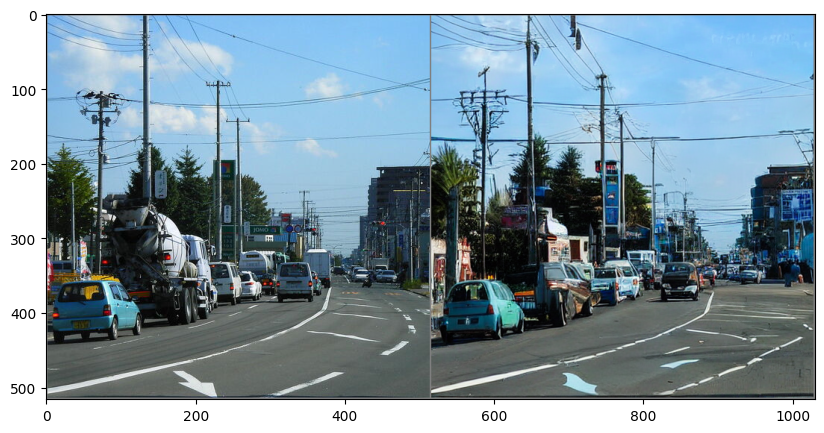

In [26]:
decoded_denoised_edm = decode_image(pipeline, result)

img = tv_make_grid(torch.cat([x_clean, decoded_denoised_edm]), nrow=2)
plt.imshow(show_image(img))
plt.show()

# Integrating Stable Diffusion as the prior step of PNPDM

In [24]:
from pnpdm.tasks import SuperResolution, GaussianNoise
from torchvision import transforms
from monai.metrics import PSNRMetric, SSIMMetric
from taming.modules.losses.lpips import LPIPS
from tqdm import tqdm

from collections import defaultdict

In [25]:
def force(pipeline, operator, x_cur, x_initial, y, sigma, rho):
    # forward operator is A(D(z))
    x_cur2 = x_cur.clone()
    x_cur2.requires_grad = True
    decoded = decode_image(pipeline, x_cur2).to(torch.float32)  # super-resolution only supports float32
    data_fit = (operator.forward(decoded).to(torch.float16) - y).norm()**2 / (2*sigma**2)
    grad = torch.autograd.grad(outputs=data_fit, inputs=x_cur2)[0]
    return (grad + (x_cur - x_initial)/rho**2)

In [82]:
def proximal_generator(pipeline, operator, x_initial, y, sigma, rho):
    gamma=5
    num_iters=50
    vel_scale=3
    delta=0.01

    # for underdamped Langevin, we have
    # K = 1, 1 - eta = gamma*delta + o(delta)
    K = 1
    eta = 1 - gamma*delta

    # initialize position
    x = x_initial.clone()
    x.requires_grad = False

    # initialize velocity
    v = torch.randn_like(x_initial) * vel_scale
    v.requires_grad = False

    images = []

    for i in range(num_iters):
        for _ in range(K):
            x += delta/2 * v
            v += - delta * force(pipeline, operator, x, x_initial, y, sigma, rho)
            x += delta/2 * v

        v = eta*v + np.sqrt(1 - eta**2) * torch.randn_like(v)

    return x # + rho * torch.randn_like(x)

In [176]:
def pnpdm(operator, noiser, pipeline, schedule, text_prompt, gt, y_n, config={}):
    transform = transforms.Compose([
        transforms.Normalize((0.5), (0.5))  # scales [0, 1] to [-1, 1]
    ])
    inv_transform = transforms.Compose([
        transforms.Normalize((-1), (2)),  # scales [-1, 1] to [0, 1]
        transforms.Lambda(lambda x: x.clamp(0, 1).detach())
    ])
    
    metrics = {
        'psnr': PSNRMetric(max_val=1),
        'ssim': SSIMMetric(spatial_dims=2),
        'lpips': LPIPS().to(device).eval(),
    }
    
    encoded_text = encode_text(pipeline, text_prompt)

    log = defaultdict(list)
    cmap = 'gray' if gt.shape[1] == 1 else None

    x = operator.initialize(gt, y_n).to(torch.float16)
    x_latent = encode_image(pipeline, x)

    # logging
    x_save = inv_transform(x)
    z_save = torch.zeros_like(x_save)
    
    for name, metric in metrics.items():
        log[name].append(metric(x_save, inv_transform(gt)).item())

    xs_save = torch.cat((inv_transform(gt), x_save), dim=-1).detach().cpu()
    try:
        zs_save = torch.cat((inv_transform(y_n.reshape(*gt.shape)), z_save), dim=-1).detach().cpu()
    except:
        try:
            zs_save = torch.cat((inv_transform(operator.A_pinv(y_n).reshape(*gt.shape)), z_save), dim=-1).detach().cpu()
        except:
            zs_save = torch.cat((z_save, z_save), dim=-1).detach().cpu()

    log["gt"] = inv_transform(gt).permute(0, 2, 3, 1).squeeze()
    log["x"].append(x_save.permute(0, 2, 3, 1).squeeze().detach())
    log["rho"] = []

    sub_pbar = tqdm(range(config["num_iters"]))
    for i in sub_pbar:
        # rho_iter = config["rho"] * (config["rho_decay_rate"]**i)
        # rho_iter = max(rho_iter, config["rho_min"])

        # have rho decrease exponentially to rho_min (e.g. decay_rate is a function of rho, rho_min, and num_iters)
        alpha = np.exp(np.log(config["rho_min"] / config["rho"]) / config["num_iters"])
        rho_iter = config["rho"] * (alpha**i)
        # rho_iter = 1.0
        log["rho"].append(rho_iter)

        # likelihood step
        z_latent = proximal_generator(pipeline, operator, x_latent, y_n, noiser.sigma, rho_iter)
        z = decode_image(pipeline, z_latent)
    
        # prior step
        #convert to float16
        # z_latent = z_latent.to(torch.float16)
        x_latent = denoise(pipeline, schedule, z_latent, rho_iter, encoded_text)
        #convert back to float32
        # x_latent = x_latent.to(torch.float32)
        x = decode_image(pipeline, x_latent)

        # logging
        x_save = inv_transform(x)
        z_save = inv_transform(z)
        for name, metric in metrics.items():
            log[name].append(metric(x_save, inv_transform(gt)).item())
        sub_pbar.set_description(f'running PnP-EDM (xrange=[{x.min().item():.2f}, {x.max().item():.2f}], zrange=[{z.min().item():.2f}, {z.max().item():.2f}]) | psnr: {log["psnr"][-1]:.4f}')

        if i % (config["num_iters"] // 10) == 0:
            xs_save = torch.cat((xs_save, x_save.detach().cpu()), dim=-1)
            zs_save = torch.cat((zs_save, z_save.detach().cpu()), dim=-1)
        
        log["x"].append(x_save.permute(0, 2, 3, 1).squeeze().cpu().numpy())

    # logging
    xz_save = torch.cat((xs_save, zs_save), dim=-2).permute(0, 2, 3, 1).squeeze().cpu().numpy()

    return xz_save, log

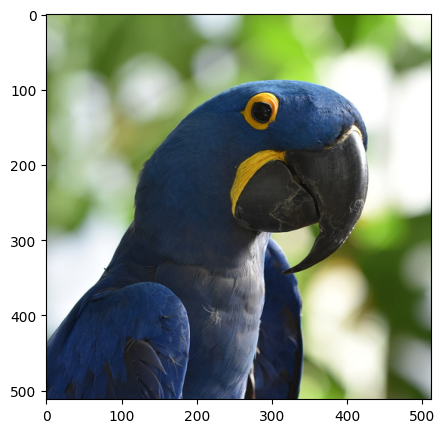

In [66]:
gt = read_image("images/512/test_image_8.png", dtype=torch.float32)
plt.imshow(show_image(gt))
plt.show()

In [67]:
noiser = GaussianNoise(0.10)
superresolution = SuperResolution(3, IMAGE_SIZE, 8, device)

In [68]:
y_n = noiser(superresolution.forward(gt))

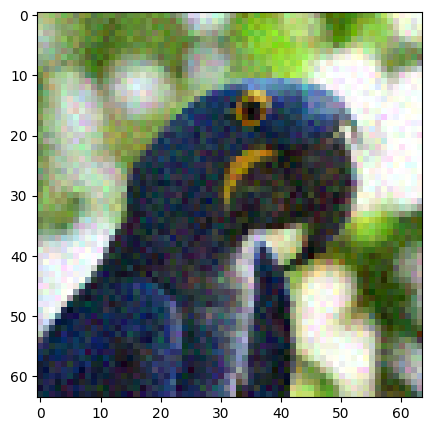

In [69]:
downsampled = y_n.reshape(1, 3, 512//8, 512//8)
plt.imshow(show_image(downsampled))

In [177]:
config = {
    "num_iters": 50,
    "rho": 5.0,
    "rho_min": 0.03,
    # "rho_decay_rate": 0.9,
}

exp_name = "rho-exp-5.0-to-0.03"

xz_save, log = pnpdm(superresolution, noiser, pipeline, schedule, "A high-quality photo of a blue macaw with a black beak", gt, y_n, config)

loaded pretrained LPIPS loss from taming/modules/autoencoder/lpips/vgg.pth


  0%|                                                                                                                                                                                                              | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_633063/165516041.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  c_noise = sigma_inv(torch.tensor(s, device=device))
running PnP-EDM (xrange=[-1.01, 1.04], zrange=[-1.02, 1.03]) | psnr: 25.4306: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [07:55<00:00,  9.51s/it]


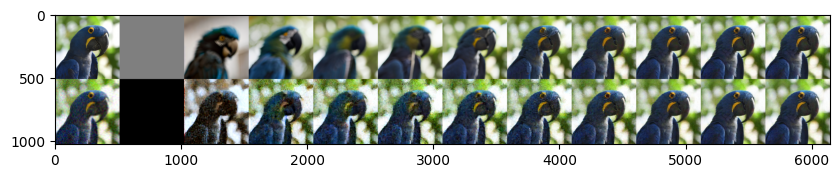

In [178]:
plt.imshow(xz_save)
plt.savefig(f"figures/{exp_name}-xz.png", dpi=300)
plt.show()

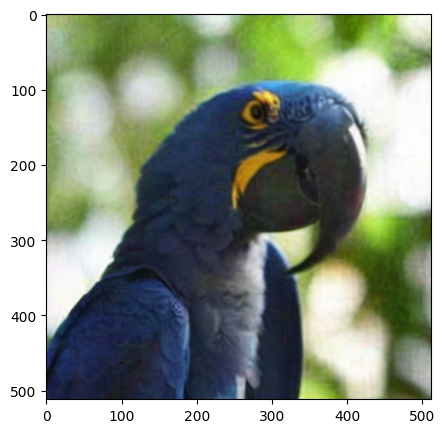

In [179]:
i = 0
plt.imshow(xz_save[:512, -512 * (i + 1):])
plt.savefig(f"figures/{exp_name}-final.png", dpi=300)
plt.show()

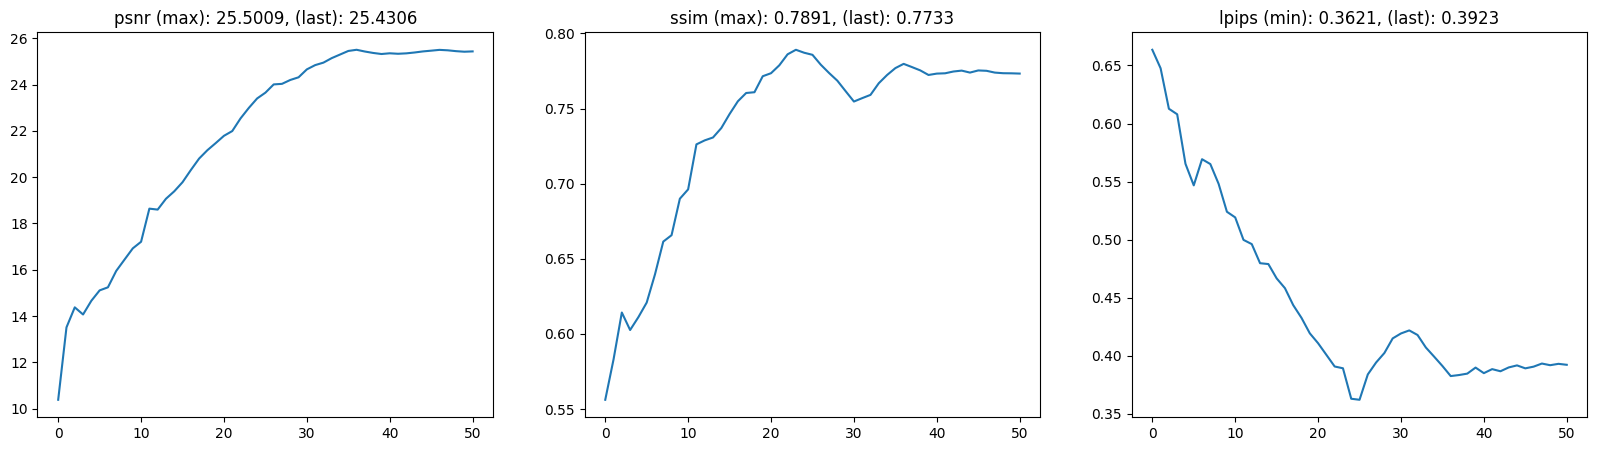

In [180]:
plt.close("a")
plt.figure(figsize=(20, 5), num="a")
plt.subplot(1, 3, 1)
plt.plot(log["psnr"])
plt.title(f'psnr (max): {np.amax(log["psnr"]):.4f}, (last): {log["psnr"][-1]:.4f}')
plt.subplot(1, 3, 2)
plt.plot(log["ssim"])
plt.title(f'ssim (max): {np.amax(log["ssim"]):.4f}, (last): {log["ssim"][-1]:.4f}')
plt.subplot(1, 3, 3)
plt.plot(log["lpips"])
plt.title(f'lpips (min): {np.amin(log["lpips"]):.4f}, (last): {log["lpips"][-1]:.4f}')
plt.savefig(f"figures/{exp_name}-metrics.png", dpi=300)
plt.show()